In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# LOAD USERS DATA
users_df = pd.read_csv('../data/raw/users.csv')

# INSPECT DATA
print(users_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 14306064 entries, 0 to 14306063
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   products  int64
 2   reviews   int64
dtypes: int64(3)
memory usage: 327.4 MB
None


In [4]:
users_df.head()

,user_id,products,reviews
0,7360263,359,0
1,14020781,156,1
2,8762579,329,4
3,4820647,176,4
4,5167327,98,2


In [5]:
# CHECK MISSING VALUES
print(users_df.isnull().sum())


user_id     0
products    0
reviews     0
dtype: int64


In [6]:
users_df.duplicated().sum()

np.int64(0)

In [7]:
print(f"Total de usuarios originales: {len(users_df)}")

Total de usuarios originales: 14306064


In [8]:
# REMOVE DUPLICATE USERS
cleaned_users_df = users_df.drop_duplicates()

In [9]:
# Resumen numérico
print("User statistics:")
print(cleaned_users_df[['products', 'reviews']].describe())

User statistics:
           products       reviews
count  1.430606e+07  1.430606e+07
mean   1.163734e+02  2.876738e+00
std    2.438515e+02  7.987421e+00
min    0.000000e+00  0.000000e+00
25%    2.300000e+01  1.000000e+00
50%    5.500000e+01  1.000000e+00
75%    1.270000e+02  3.000000e+00
max    3.221400e+04  6.045000e+03


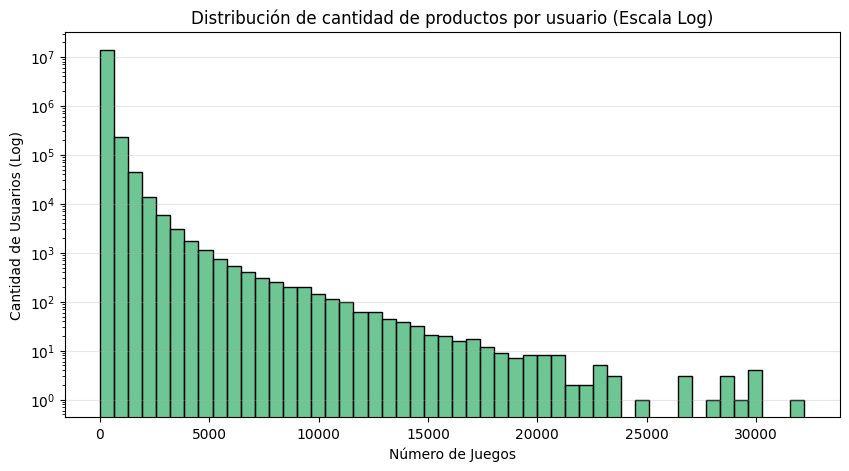

In [10]:
plt.figure(figsize=(10, 5))
# Quitamos el kde=True para que no ensucie la escala logarítmica
sns.histplot(cleaned_users_df['products'], bins=50, color='mediumseagreen', kde=False)
plt.yscale('log') 
plt.title('Distribución de cantidad de productos por usuario (Escala Log)')
plt.xlabel('Número de Juegos')
plt.ylabel('Cantidad de Usuarios (Log)')
plt.grid(axis='y', alpha=0.3)
plt.show()

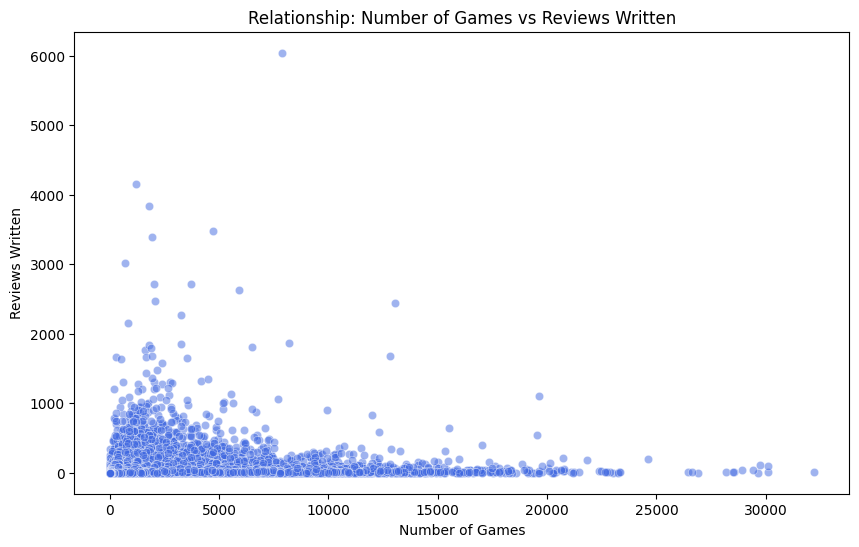

In [11]:
# 2. Relationship between Products and Reviews
# Do those who own more games write more reviews?
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cleaned_users_df, x='products', y='reviews', alpha=0.5, color='royalblue')
plt.title('Relationship: Number of Games vs Reviews Written')
plt.xlabel('Number of Games')
plt.ylabel('Reviews Written')
plt.show()

In [12]:
# SAVE CLEANED USERS
cleaned_users_df.to_csv('../data/processed/users_cleaned.csv', index=False)
print("CLEANED USERS SAVED.")

CLEANED USERS SAVED.
